### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'import matplotlib.
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/tmp/ipykernel_1102366/4210131411.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


,IndivID,PopID,Pop,Country,Continent,sex,lat,long,L1.125,L1.130,...,L677.255.553287981859,L677.259,L677.263,L677.267,L678.202,L678.206,L678.209.848101265823,L678.210,L678.214,L678.218
Chipewyan29,2012,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,0,1,0,0
Chipewyan31,2156,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,1,0,0,0
Chipewyan33,2381,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,1,0,0,0,0
Chipewyan35,2382,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,0,1,0,0
Chipewyan37,2383,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,1,0,0,0,0,0,1,0,0


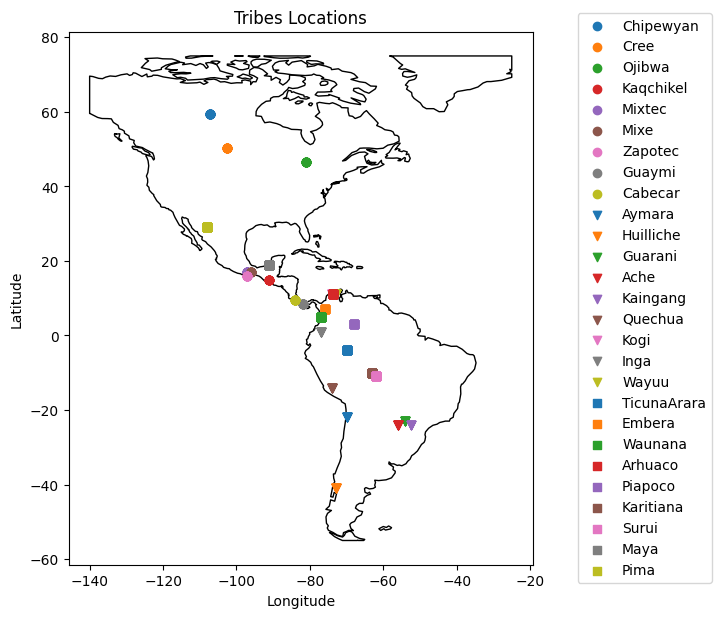

In [79]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
df.head()

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [80]:
import numpy as np

# X = genetic markers
X = df.iloc[:, 8:].values

# y = longitude
y = longitude

XtX = X.T @ X

# compute Xty
Xty = X.T @ y

# solve the linear system
beta = np.linalg.solve(XtX, Xty)

LinAlgError: Singular matrix

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [81]:
beta_lstsq, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)

print(f"we get :{beta_lstsq.shape} estimators")
print("rank(X) =", rank)
print(beta_lstsq)

we get :(5709,) estimators
rank(X) = 494
[-0.04005781 -0.01940898  0.01111306 ... -0.21729626 -0.10210421
  0.01813644]


Using `numpy.linalg.lstsq`, we do not get the singular matrix error anymore.  
This is because `numpy.linalg.solve` and `numpy.linalg.lstsq` solve different types of problems.

The function `numpy.linalg.solve` attempts to solve an exact linear system of the form

$$
A\beta = b
$$

and requires the matrix $A$ to be **square and full rank** (i.e., invertible).  
In our case, we tried to solve the normal equations

$$
(X^T X)\beta = X^T y
$$

using `solve`. However, this fails because the matrix $X^T X$ is **singular**.

Indeed, in our dataset we have $p = 5709$ predictors and $N = 494$ observations, so

$$
p > N
$$

and therefore the rank of $X$ satisfies

$$
\mathrm{rank}(X) \leq N < p.
$$

This means that the columns of $X$ are linearly dependent and consequently $X^T X$ is not invertible.  
For this reason, `numpy.linalg.solve` raises a **singular matrix error**.

In contrast, `numpy.linalg.lstsq` does not try to invert $X^T X$.  
Instead, it directly solves the least squares problem

$$
\min_{\beta} \|y - X\beta\|^2
$$

using numerical methods based on the **singular value decomposition (SVD)**.  
This approach works even when $X$ is not full rank and the solution is not unique.

Therefore, while `solve` fails because $X^T X$ is singular, `lstsq` is still able to return one least-squares solution (specifically, the solution with minimum Euclidean norm).

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

[-0.20081492  0.00058007  0.03317267 ...  0.04589671 -0.0893951
  0.01925555]
[-0.04005781 -0.01940898  0.01111306 ... -0.21729626 -0.10210421
  0.01813644]


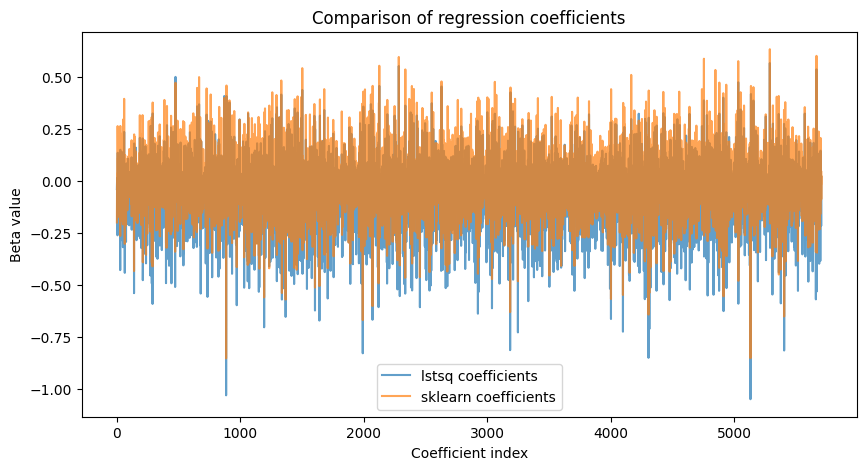

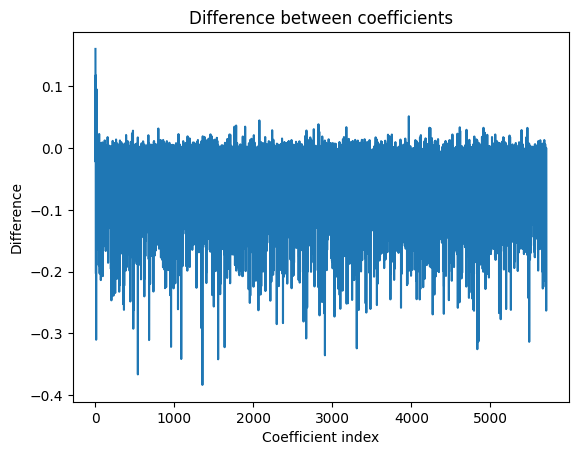

In [82]:
from sklearn.linear_model import LinearRegression
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
beta_sklearn = lr.coef_

print(beta_sklearn)
print(beta_lstsq)
# indexes for coefficients
idx = np.arange(len(beta_lstsq))

plt.figure(figsize=(10,5))

plt.plot(idx, beta_lstsq, label="lstsq coefficients", alpha=0.7)
plt.plot(idx, beta_sklearn, label="sklearn coefficients", alpha=0.7)

plt.xlabel("Coefficient index")
plt.ylabel("Beta value")
plt.title("Comparison of regression coefficients")
plt.legend()

plt.show()

plt.plot(beta_lstsq - beta_sklearn)
plt.title("Difference between coefficients")
plt.xlabel("Coefficient index")
plt.ylabel("Difference")
plt.show()

The coefficients obtained with `sklearn.linear_model.LinearRegression` are not exactly the same as those obtained with `numpy.linalg.lstsq`. This happens because `sklearn` automatically centers the predictors before estimating the regression coefficients.

More precisely, each predictor is transformed as

$$
X_j^{centered} = X_j - \bar{X}_j
$$

where $\bar{X}_j$ is the mean of predictor $j$.

This re-centering changes the estimated coefficients and the intercept of the model.

A practical reason for performing this centering is related to the interpretation of the intercept. In a linear regression model

$$
y = \beta_0 + X\beta
$$

the intercept $\beta_0$ represents the predicted value of $y$ when all predictors are equal to zero. However, in many practical situations this point may not correspond to a meaningful or realistic observation.

By centering the predictors, the value $X^{centered}=0$ corresponds to an individual with **average predictors**. Therefore the intercept becomes the predicted response for an average individual, which is easier to interpret.
In fact, isn a linear regression model, the intercept corresponds to the predicted value when all predictors are equal to zero. However, this situation may not correspond to a realistic observation in the dataset.

By centering the predictors, the value zero corresponds to the average value of each predictor. Therefore the intercept represents the predicted response for an individual with average predictors, which is easier to interpret.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

Principal Component Analysis (PCA) is a dimensionality reduction technique used to transform a set of possibly correlated variables into a smaller number of uncorrelated variables called **principal components**.

From a **geometric point of view**, PCA can be seen as a rotation of the coordinate system. The data points in a high-dimensional space are projected onto new orthogonal axes (the principal components). The first principal component is the direction in which the data varies the most, i.e., the direction that maximizes the variance of the projected data. The second principal component is orthogonal to the first and captures the next largest possible variance, and so on. This can be interpreted as finding the directions that best describe the spread of the data cloud.

From a **statistical point of view**, PCA consists in computing the eigenvectors and eigenvalues of the covariance matrix of the data. The eigenvectors define the directions of the principal components, while the eigenvalues measure the amount of variance explained by each component. By keeping only the components associated with the largest eigenvalues, we can reduce the dimensionality of the data while preserving most of its variability.

In practice, PCA allows us to summarize high-dimensional data using a small number of components that retain most of the information present in the original variables.

For a more technical explanation look bellow.

## Principal Component Analysis (PCA) and Explained Variance

Let $ X \in \mathbb{R}^{m \times k} $ be a matrix of embeddings, where each column $ x_i $ is a normalized embedding vector of dimension $ m $.

---

### Centering the Data

To apply PCA, we first center the data around its mean:

$$
\mu = \frac{1}{k} \sum_{i=1}^{k} x_i \in \mathbb{R}^{m}, \quad
\tilde{X} = X - \mu \mathbf{1}^\top
$$

where $ \mathbf{1} \in \mathbb{R}^{k} $ is a vector of ones.

Centering ensures that the first principal component captures the **direction of maximum variance** around the data center.


### Covariance Matrix

Next, we compute the covariance matrix:

$$
\Sigma = \frac{1}{k} \tilde{X} \tilde{X}^\top \in \mathbb{R}^{m \times m}
$$

This matrix describes how different dimensions are correlated.


### Spectral Decomposition

We compute the eigenvalues and eigenvectors of $\Sigma$:

$$
\Sigma v_i = \lambda_i v_i, \quad i=1,\dots,m
$$

where:

- $ v_i $ are the eigenvectors (principal directions, orthonormal)  
- $ \lambda_i \ge 0 $ are the eigenvalues (variance explained by $ v_i $)

Ordering the eigenvalues in descending order $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_m$ gives the principal components in decreasing importance of variance.


### Projecting the Data

Each centered vector $\tilde{x}_i$ can be projected onto the principal components:

$$
y_i = V^\top \tilde{x}_i \in \mathbb{R}^{m}, \quad
V = [v_1, v_2, \dots, v_m]
$$

So:

- $ y_i[1] $ = projection onto the 1st principal component  
- $ y_i[2] $ = projection onto the 2nd, etc.

PCA rewrites the data in a basis where axes are **uncorrelated** and ordered by explained variance.


### Explained Variance

The total variance of the centered matrix is:

$$
\text{Var}_{\text{total}} = \sum_{i=1}^{m} \lambda_i = \text{trace}(\Sigma)
$$

The proportion of variance explained by component $i$ is:

$$
\text{ratio}_i = \frac{\lambda_i}{\sum_{j=1}^{m} \lambda_j} \in [0,1]
$$

The cumulative variance of the first $r$ components is:

$$
\text{explained}_r = \sum_{i=1}^{r} \text{ratio}_i
$$

It represents the fraction of total variance captured by the first $r$ principal directions.  

- If $\text{explained}_2 \approx 1$, the points are almost **in a 2D plane**  
- If $\text{explained}_1 \approx 1$, the points are almost aligned (effective dimension = 1)


### Geometric Interpretation in Embeddings

In the case of dimensional collapse:

- Embeddings are initially spread on the 3D unit sphere  
- PCA identifies the **plane or line** where vectors concentrate during collapse  
- Eigenvalues that shrink correspond to lost dimensions

Thus, PCA provides a **quantitative measure of collapse** via cumulative explained variance:

$$
\text{effective rank} \approx \#\{\lambda_i \text{ significant}\}
$$

### Summary

1. Center the data  
2. Compute the covariance matrix  
3. Extract eigenvectors and eigenvalues ($v_i, \lambda_i$)  
4. Explained variance: $\text{ratio}_i = \lambda_i / \sum \lambda_j$  
5. Cumulative variance: $\text{explained}_r = \sum_{i=1}^r \text{ratio}_i$  
6. Geometric interpretation: the more variance is concentrated in fewer components, the more severe the collapse.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

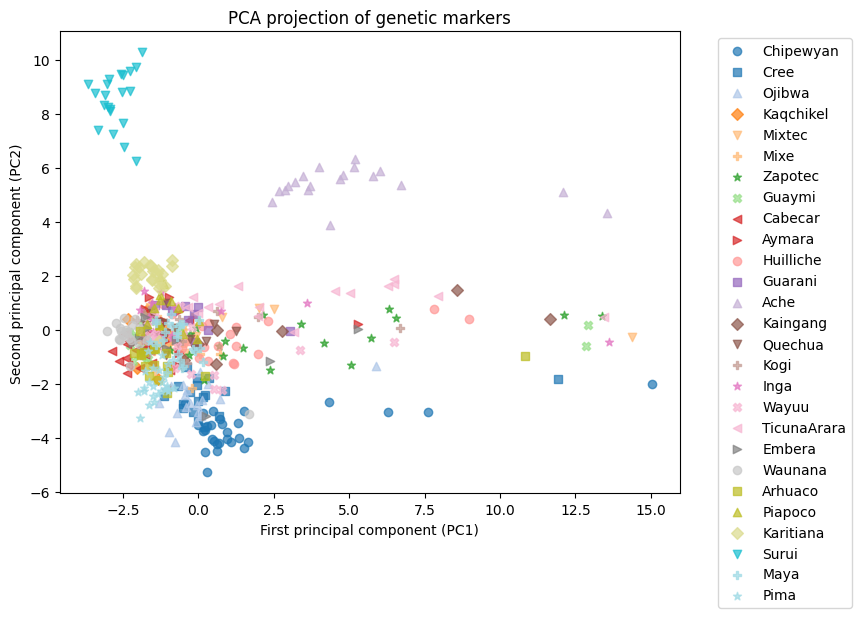

In [83]:
from sklearn.decomposition import PCA
# tribe labels
tribes = df['Pop']

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plotting and classification tools
unique_tribes = tribes.unique()

# markers and colors
markers = ['o','s','^','D','v','P','*','X','<','>']
colors = plt.cm.tab20(np.linspace(0,1,len(unique_tribes)))

plt.figure(figsize=(8,6))

for i, tribe in enumerate(unique_tribes):
    
    idx = []

    for t in tribes:
        if t == tribe:
            idx.append(True)
        else:
            idx.append(False)
    
    
    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=tribe,
        marker=markers[i % len(markers)],
        color=colors[i],
        alpha=0.7
    )

plt.xlabel("First principal component (PC1)")
plt.ylabel("Second principal component (PC2)")
plt.title("PCA projection of genetic markers")

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

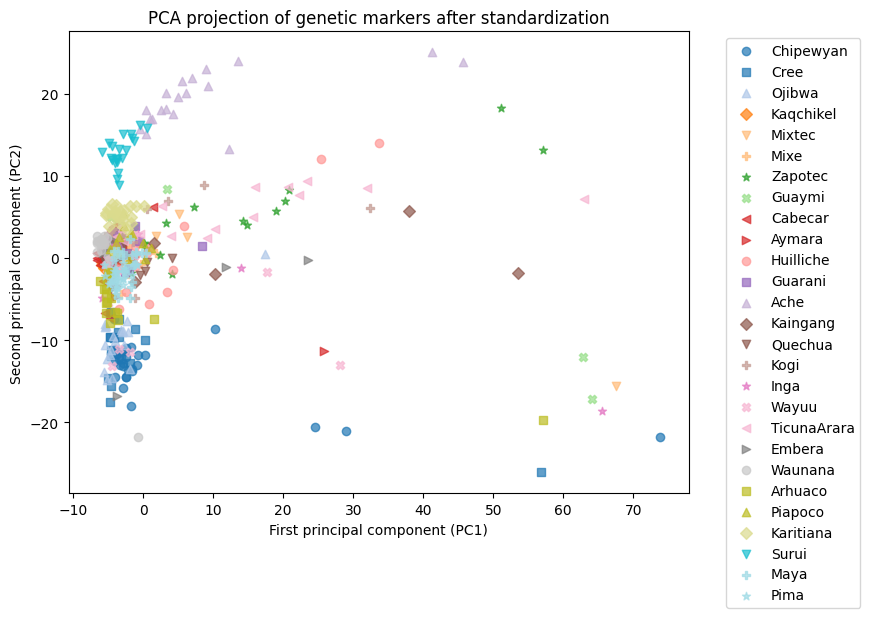

In [84]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

# PCA on standerized data
pca_std = PCA(n_components=2)
X_pca_std = pca_std.fit_transform(X_std)

# Plotting and classification tools
unique_tribes = tribes.unique()


markers = ['o','s','^','D','v','P','*','X','<','>']
colors = plt.cm.tab20(np.linspace(0,1,len(unique_tribes)))

plt.figure(figsize=(8,6))

for i, tribe in enumerate(unique_tribes):
    
    idx = []

    for t in tribes:
        if t == tribe:
            idx.append(True)
        else:
            idx.append(False)
    
    
    plt.scatter(
        X_pca_std[idx,0],
        X_pca_std[idx,1],
        label=tribe,
        marker=markers[i % len(markers)],
        color=colors[i],
        alpha=0.7
    )

plt.xlabel("First principal component (PC1)")
plt.ylabel("Second principal component (PC2)")
plt.title("PCA projection of genetic markers after standardization")

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.show()


Standardization transforms each variable so that it has **mean 0 and variance 1**.

For a variable $x_j$, the standardized value is computed as

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

where

- $x_{ij}$ is the value of variable $j$ for observation $i$
- $\mu_j$ is the mean of variable $j$
- $\sigma_j$ is the standard deviation of variable $j$

After this transformation:

$$
E[z_j] = 0, \qquad Var(z_j) = 1
$$

This preprocessing step is important because **PCA is based on the covariance matrix of the data**.  
If variables have very different scales or variances, those with the largest variance will dominate the first principal components. Standardization ensures that **all variables contribute equally** to the analysis.

**Comparison with the previous PCA plot**

After performing PCA on the standardized dataset, the scatter plot changes slightly in scale, but the **overall geometric structure remains very similar** to the one obtained without standardization.

The main clusters corresponding to the different tribes are still visible and appear in roughly the same relative positions in the two plots. This indicates that the directions of maximum variance in the data are essentially the same before and after scaling.

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

Since the PCA results are very similar with and without standardization, this suggests that the genetic markers in this dataset are already measured on **comparable scales**. Therefore, no particular variable strongly dominates the PCA because of its magnitude.

Consequently, standardization does not significantly change the structure revealed by PCA for this dataset, although it remains a good general practice when variables may have different units or scales.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

Variance explained by PC1: 2.05003082521713 %
Variance explained by PC2: 1.5184136989967854 %
Variance explained by first two PCs: 3.568444524213916 %
Number of components needed for 95% variance: 410


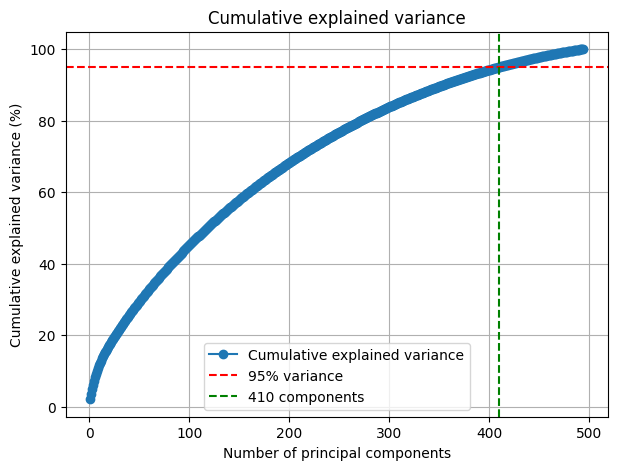

In [85]:
pca_full = PCA()
pca_full.fit(X)

explained_variance = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_variance)

print(f"Variance explained by PC1: {explained_variance[0]*100} %")
print(f"Variance explained by PC2: {explained_variance[1]*100} %")
print(f"Variance explained by first two PCs: {(explained_variance[0]+explained_variance[1])*100} %")

# minimum number of components required to reach 95% variance
n_components_95 = np.argmax(cum_explained >= 0.95) + 1
print(f"Number of components needed for 95% variance: {n_components_95}")

plt.figure(figsize=(7,5))

plt.plot(range(1,len(cum_explained)+1), cum_explained*100, marker='o', label="Cumulative explained variance")

# horizontal line indicating the 95% variance threshold
plt.axhline(y=95, color='red', linestyle='--', label="95% variance")

# vertical line showing the number of components needed
plt.axvline(x=n_components_95, color='green', linestyle='--',
            label=f"{n_components_95} components")

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance (%)")
plt.title("Cumulative explained variance")
plt.grid(True)
plt.legend()

plt.show()

The first two principal components explain $3.57%$ of the total variance.
By analyzing the cumulative explained variance curve, we observe that approximately $410$ principal components are required to capture $95%$ of the variance.
Therefore, if we want a compact representation of the genetic markers while preserving most of the information, we should keep about $410$ principal components to have a good idea of the Data.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

In [86]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt


def pcr_predict_coordinates(X, latitude, longitude, n_components=250):
    """
    Perform PCA on X, then regress latitude and longitude
    on the PCA scores.

    Returns:
        pca, reg_lat, reg_lon, lat_pred, lon_pred
    """
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    reg_lat = LinearRegression()
    reg_lon = LinearRegression()

    reg_lat.fit(X_pca, latitude)
    reg_lon.fit(X_pca, longitude)

    lat_pred = reg_lat.predict(X_pca)
    lon_pred = reg_lon.predict(X_pca)

    return pca, reg_lat, reg_lon, lat_pred, lon_pred


def plot_predicted_map(df, lat_pred, lon_pred, title="Predicted geographic locations from genetic markers"):
    """
    Plot predicted geographic coordinates using the same style
    as in Exercise 1.
    """
    world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

    fig, ax = plt.subplots(figsize=(8.0, 6.5))
    plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

    world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

    marker_list = ['o', 'v', 's']
    colors_list = [f'C{i}' for i in range(9)]

    for i, tribe in enumerate(df['Pop'].unique()):
        members = df['Pop'] == tribe

        ax.scatter(
            lon_pred[members],
            lat_pred[members],
            marker=marker_list[i // 9],
            color=colors_list[i % 9],
            label=tribe
        )

    ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.show()

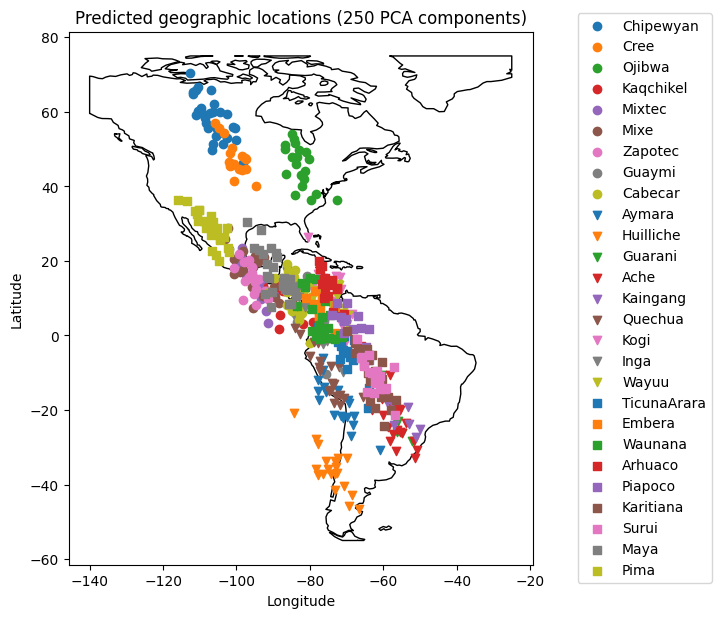

In [87]:
pca_250, reg_lat_250, reg_lon_250, lat_pred_250, lon_pred_250 = pcr_predict_coordinates(
    X, latitude, longitude, n_components=250
)

plot_predicted_map(
    df,
    lat_pred_250,
    lon_pred_250,
    title="Predicted geographic locations (250 PCA components)"
)

In [88]:
print(f"250 pca componenets explain about {cum_explained[249]*100} % of the variance of the Data")

250 pca componenets explain about 76.78145776791465 % of the variance of the Data


We predict the latitude and longitude of the individuals using a linear regression model based on the scores of the first 250 PCA components of the genetic markers.

The first 250 principal components capture approximately **76.8% of the total variance** in the genetic markers. Therefore, the regression model uses most of the information contained in the dataset while reducing the dimensionality of the original genetic data.

When comparing the predicted map with the original map from Exercise 1, we observe that the predicted locations roughly reproduce the global geographical structure of the populations. Individuals from northern populations are predicted in northern regions, while individuals from Central and South America are predicted further south. This indicates that genetic variation contains information related to geographical origin.

However, the predicted map appears **more dispersed** than the true map: individuals from the same tribe are spread over larger regions rather than concentrated in a single location. This shows that the regression model does not perfectly recover the exact geographic coordinates.

Moreover, the map may also be **too optimistic** regarding the ability to infer the geographical origin of individuals outside the dataset. The regression model is trained and evaluated on the same individuals, which means it may capture patterns specific to the dataset rather than general geographic relationships. If we were to predict the location of individuals not present in the training data, the prediction errors would likely be larger.

Therefore, although genetic markers contain meaningful geographical information, the model should not be interpreted as providing highly precise geographic localization for new individuals.

In other words, this models leaks Data and Overfits.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [89]:
from sklearn.metrics.pairwise import haversine_distances

def mean_haversine_error(latitude, longitude, lat_pred, lon_pred, earth_radius_km=6371):
    """
    Compute the mean Haversine distance between true and predicted coordinates.
    """
    
    # true coordinates in radians
    real_coords = np.radians(np.column_stack((latitude, longitude)))
    
    # predicted coordinates in radians
    pred_coords = np.radians(np.column_stack((lat_pred, lon_pred)))
    
    # pairwise angular distances
    D = haversine_distances(real_coords, pred_coords)
    
    # diagonal = distance between true and predicted location for each individual
    mean_distance_km = np.mean(np.diag(D)) * earth_radius_km
    
    return mean_distance_km

In [90]:
err_250 = mean_haversine_error(latitude, longitude, lat_pred_250, lon_pred_250)
print("Mean prediction error (250 PCA):", err_250, "km")

Mean prediction error (250 PCA): 627.8124897245468 km


To quantify the prediction error, we compute the mean geographical distance between the real coordinates and the predicted coordinates using the Haversine distance. This distance measure accounts for the curvature of the Earth and is therefore appropriate for geographic coordinates.


The Haversine distance provides an explicit formula for this spherical distance.
Let $ (\phi_i, \lambda_i) $ be the true latitude and longitude of individual $i$, and  
$ (\hat{\phi}_i, \hat{\lambda}_i) $ the predicted coordinates.

The Haversine distance between the two points on the Earth's surface is

$$
d_i = 2R \arcsin\left(
\sqrt{
\sin^2\left(\frac{\hat{\phi}_i - \phi_i}{2}\right)
+
\cos(\phi_i)\cos(\hat{\phi}_i)
\sin^2\left(\frac{\hat{\lambda}_i - \lambda_i}{2}\right)
}
\right)
$$

where

- $R = 6371$ km is the radius of the Earth,
- $\phi$ denotes latitude,
- $\lambda$ denotes longitude,
- all angles are expressed in **radians**.

This formula computes the **great-circle distance** between the two points.

Using the Haversine distance is mathematically appropriate in this context because:

1. The observations lie on the **surface of a sphere**, not in a flat Euclidean plane.
2. Euclidean distance between $(\phi,\lambda)$ coordinates would ignore the Earth's curvature and would produce biased distances, especially for points far apart.
3. The Haversine formula directly measures the **true geodesic distance along the Earth's surface**, which corresponds to the meaningful geographic error between the real and predicted locations.

Therefore, the Haversine distance provides a correct measure of the geographical prediction error of the regression model.
The mean prediction error is then

$$
\frac{1}{n}\sum_{i=1}^{n} d_i
$$

In our case, the mean prediction error is approximately **644.5 km**.

This means that, on average, the predicted geographic location of an individual based on its genetic markers differs from the true location by about **645 kilometers**. This confirms that while genetic markers contain information related to geographic origin, the prediction remains relatively imprecise and should only be interpreted as a coarse estimate of an individual's location.

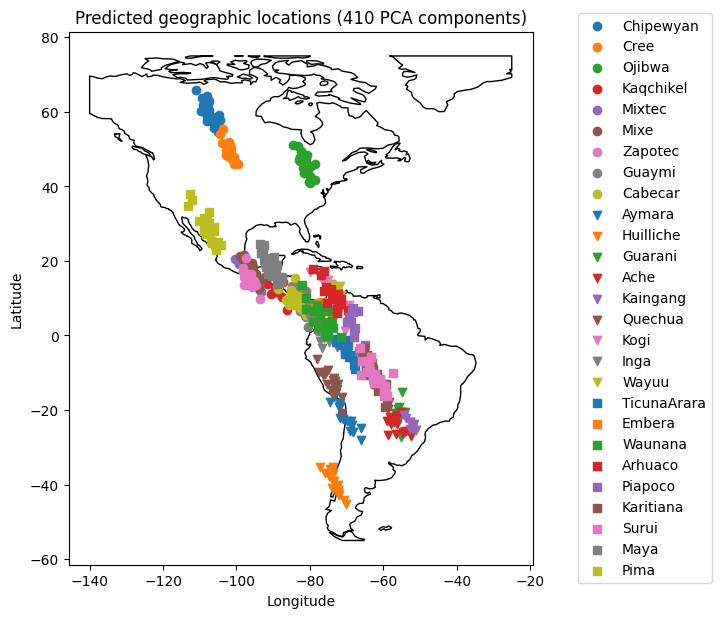

In [91]:
pca_410, reg_lat_410, reg_lon_410, lat_pred_410, lon_pred_410 = pcr_predict_coordinates(
    X, latitude, longitude, n_components=410
)

plot_predicted_map(
    df,
    lat_pred_410,
    lon_pred_410,
    title="Predicted geographic locations (410 PCA components)"
)

In [92]:
err_410 = mean_haversine_error(latitude, longitude, lat_pred_410, lon_pred_410)
print("Mean prediction error (410 PCA):", err_410, "km")

Mean prediction error (410 PCA): 335.4455257528761 km


**Bonus**

When increasing the number of components to **410 PCA axes**, which explain approximately **90% of the total variance** (like we've demonstrated in the previous exercise), the predictions become significantly more accurate. The predicted points are more concentrated around the true geographical regions of the tribes, and the spatial structure of the populations is better preserved. In this case, the mean prediction error decreases to about **335 km**, showing that including more principal components improves the reconstruction of geographic coordinates.

However,We must remind you that this map should be interpreted cautiously. The regression model is trained and evaluated on the **same individuals**, meaning that the model may exploit patterns specific to the dataset. As a consequence, the resulting map likely illustrates **too optimistically** the ability to infer the geographical origin of individuals **outside the database** from their genetic markers. In practice, predicting the location of new individuals would likely produce larger errors.

## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

Cross-validation is a model evaluation procedure used to estimate how well a predictive model generalizes to unseen data.

In $K$-fold cross-validation, the dataset is partitioned into $K$ disjoint subsets (folds). For each iteration, one fold is used as the test set while the remaining $K-1$ folds are used to train the model. The procedure is repeated $K$ times so that every observation is used once for testing. The prediction errors are then averaged across the folds to obtain an estimate of the generalization error.

Cross-validation is useful because it allows us to evaluate the predictive performance of a model while reducing the risk of overfitting. It also helps selecting model hyperparameters, such as the number of principal components in PCR.

However, standard cross-validation assumes that the samples are **independent and identically distributed (IID)**. When this assumption is violated, specialized strategies should be used. For example:

- **GroupKFold** when observations belong to groups (e.g., individuals from the same population)
- **TimeSeriesSplit** when observations are ordered in time
- **LeaveOneGroupOut** when entire groups should be excluded during testing

These strategies prevent data leakage between training and test sets.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

The individuals in the dataset belong to different populations (tribes), and individuals from the same population are genetically related. Therefore, the observations are not fully independent.

If individuals from the same tribe appear in both the training and test sets, the model may exploit population-specific patterns and artificially reduce the prediction error. This would lead to overly optimistic estimates of the model performance.

To avoid this issue, a cross-validation strategy that keeps entire populations together in either the training or the test set is more appropriate. A suitable choice is **GroupKFold**, where the groups correspond to the population labels (`Pop`). This ensures that individuals from the same tribe are never split between the training and test folds.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [98]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold

y = np.column_stack((latitude, longitude))
groups = df['Pop']

pipeline = make_pipeline(
    PCA(n_components=4),
    LinearRegression()
)

cv = GroupKFold(n_splits=10)

train_errors = []
test_errors = []

for train_idx, test_idx in cv.split(X, y, groups):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    train_errors.append(
        mean_haversine_error(
            y_train[:,0], y_train[:,1],
            y_train_pred[:,0], y_train_pred[:,1]
        )
    )

    test_errors.append(
        mean_haversine_error(
            y_test[:,0], y_test[:,1],
            y_test_pred[:,0], y_test_pred[:,1]
        )
    )

print("Mean training error:", np.mean(train_errors))
print("Mean test error:", np.mean(test_errors))

Mean training error: 1807.3725551195585
Mean test error: 2397.0175570347064


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

In [99]:
components = range(2, 441, 10)

train_means = []
test_means = []
train_stds = []
test_stds = []

for n in components:

    pipeline = make_pipeline(
        PCA(n_components=n),
        LinearRegression()
    )

    train_errors = []
    test_errors = []

    for train_idx, test_idx in cv.split(X, y, groups):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        pipeline.fit(X_train, y_train)

        y_train_pred = pipeline.predict(X_train)
        y_test_pred = pipeline.predict(X_test)
        
        train_errors.append(mean_haversine_error(
            y_train[:,0], y_train[:,1],
            y_train_pred[:,0], y_train_pred[:,1]))

        test_errors.append(mean_haversine_error(
            y_test[:,0], y_test[:,1],
            y_test_pred[:,0], y_test_pred[:,1]))

    print("n =", n, " | nb folds =", len(train_errors))

    train_means.append(np.mean(train_errors))
    test_means.append(np.mean(test_errors))
    train_stds.append(np.std(train_errors))
    test_stds.append(np.std(test_errors))

n = 2  | nb folds = 10
n = 12  | nb folds = 10
n = 22  | nb folds = 10
n = 32  | nb folds = 10
n = 42  | nb folds = 10
n = 52  | nb folds = 10
n = 62  | nb folds = 10
n = 72  | nb folds = 10
n = 82  | nb folds = 10
n = 92  | nb folds = 10
n = 102  | nb folds = 10
n = 112  | nb folds = 10
n = 122  | nb folds = 10
n = 132  | nb folds = 10
n = 142  | nb folds = 10
n = 152  | nb folds = 10
n = 162  | nb folds = 10
n = 172  | nb folds = 10
n = 182  | nb folds = 10
n = 192  | nb folds = 10
n = 202  | nb folds = 10
n = 212  | nb folds = 10
n = 222  | nb folds = 10
n = 232  | nb folds = 10
n = 242  | nb folds = 10
n = 252  | nb folds = 10
n = 262  | nb folds = 10
n = 272  | nb folds = 10
n = 282  | nb folds = 10
n = 292  | nb folds = 10
n = 302  | nb folds = 10
n = 312  | nb folds = 10
n = 322  | nb folds = 10
n = 332  | nb folds = 10
n = 342  | nb folds = 10
n = 352  | nb folds = 10
n = 362  | nb folds = 10
n = 372  | nb folds = 10
n = 382  | nb folds = 10
n = 392  | nb folds = 10
n = 402  | 

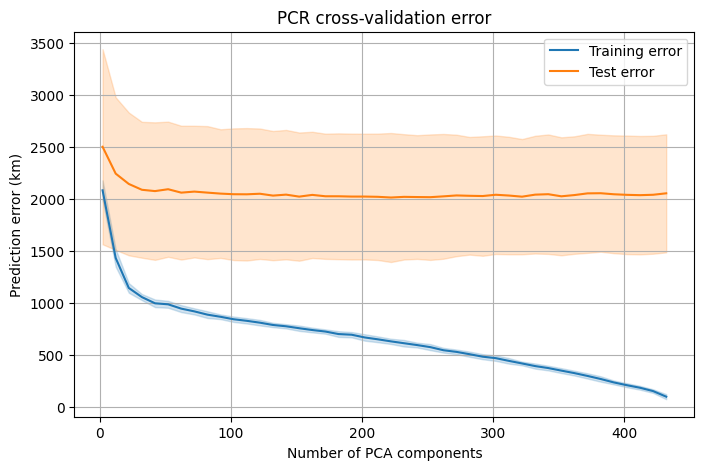

In [100]:
plt.figure(figsize=(8,5))

plt.plot(components, train_means, label="Training error", color="C0")
plt.plot(components, test_means, label="Test error", color="C1")

plt.fill_between(
    components,
    np.array(train_means)-np.array(train_stds),
    np.array(train_means)+np.array(train_stds),
    alpha=0.2,
    color="C0"
)

plt.fill_between(
    components,
    np.array(test_means)-np.array(test_stds),
    np.array(test_means)+np.array(test_stds),
    alpha=0.2,
    color="C1"
)

plt.xlabel("Number of PCA components")
plt.ylabel("Prediction error (km)")
plt.title("PCR cross-validation error")
plt.legend()
plt.grid()

plt.show()

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

From the cross-validation curve, the **test error reaches its minimum for approximately 200 PCA components**, with a prediction error of about **2000 km**. Therefore, we keep the PCR model with **around 200 principal components**.

For this model, the **training error is much smaller**, around **650–700 km**, whereas the **test error remains close to 2000 km**. This large gap indicates that the model fits the training populations much better than it generalizes to unseen populations.

The shaded areas in the plot represent the **standard deviation of the errors across the cross-validation folds**. For the training error, the variance is relatively small, indicating that the model behaves consistently across folds when evaluated on training data. In contrast, the **test error shows a larger variance**, meaning that the prediction performance varies depending on which populations are held out in the test fold. This is expected because different populations may be genetically more or less similar to those used for training.

Compared with **Exercise 4**, where the regression was trained and evaluated on the same dataset, the prediction error is now much larger. In Exercise 4 the error was only a few hundred kilometers, whereas cross-validation gives an error close to **2000 km**. This confirms that evaluating the model on the training data leads to an **overly optimistic estimate** of its predictive ability.

When plotting the predicted coordinates on a map as in Exercise 4(a), the **global geographic structure of the populations is still visible**: individuals from northern populations tend to be predicted in northern regions, while individuals from Central and South America appear further south. However, the predicted locations are **much more dispersed**, reflecting the large prediction error.

Overall, these results show that **genetic markers contain information about broad geographic origin**, allowing the model to recover large-scale geographic patterns. However, the PCR model has **limited precision when predicting the location of individuals from populations that were not present in the training data**, which explains the large cross-validation error.


## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

In this study, we investigated the relationship between **genetic markers and geographical origin** using **principal components regression (PCR)**. The PCA step allowed us to reduce the dimensionality of the genetic data while capturing the main axes of genetic variation. As the number of principal components increased, the **training error consistently decreased**, showing that the model could better fit the training populations. However, the **cross-validated test error quickly reached a plateau around 2000 km**, indicating that adding more components beyond roughly 200 did not significantly improve the model’s ability to generalize to unseen populations. This reflects the classic bias–variance trade-off: increasing the model complexity improves the fit on the training data but does not necessarily improve predictive performance on new groups, as expalined bellow:

Let $X \in \mathbb{R}^{n \times p}$ be the matrix of genetic markers and $Y \in \mathbb{R}^{n \times 2}$ the matrix of geographic coordinates **latitude and longitude**. In principal components regression $PCR$, the predictors are first projected onto the first $k$ principal components:

$$
Z_k = X V_k
$$

where $V_k = $$v_1,\dots,v_k$ contains the first $k$ eigenvectors of the covariance matrix of $X$. The regression model is then

$$
\hat{Y} = Z_k \beta_k
$$

where $\beta_k$ are the regression coefficients estimated from the training data.

The expected prediction error at a new point $x$ can be decomposed as

$$
\mathbb{E}\left[(Y - \hat{Y})^2\right] =
\underbrace{\left(\mathbb{E}[\hat{Y}] - Y\right)^2}_{\text{Bias}^2}
+
\underbrace{\mathbb{E}\left[(\hat{Y} - \mathbb{E}[\hat{Y}])^2\right]}_{\text{Variance}}
+
\underbrace{\sigma^2}_{\text{Irreducible noise}}
$$

When the number of principal components $k$ increases:

* the model becomes more flexible, which reduces the **bias** because more freedom degrees are provided so the model can shape itself into the data;
* however, the **variance of the estimator increases**, because the model becomes more sensitive to fluctuations in the training data. In fact this is a way of saying that model will overfit as it learns to handle small fluctuations in the data (in the form of less dominant PCA componenets).
A Mathematical proof is as follows :

In linear regression, the variance of the estimated coefficients is

$$
\mathrm{Var}(\hat{\beta}) = \sigma^2 (X^T X)^{-1}
$$

Therefore, the variance of the estimator depends directly on the matrix

$$
(X^T X)^{-1}.
$$


Suppose that some directions of the data matrix $X$ have very small variance.  
Then the matrix $X^T X$ can be diagonalized as

$$
X^T X = V \Lambda V^T
$$

where

$$
\Lambda = \mathrm{diag}(\lambda_1,\dots,\lambda_p)
$$

contains the eigenvalues of $X^T X$, ordered such that

$$
\lambda_1 \ge \lambda_2 \ge \cdots \ge \lambda_p .
$$

If we include a direction with very small variance,

$$
\lambda_i \approx 0
$$

then the inverse matrix

$$
(X^T X)^{-1}
$$

contains the term

$$
\frac{1}{\lambda_i},
$$

which becomes very large.

Consequently, $\mathrm{Var}(\hat{\beta})$ becomes large, meaning that the estimated regression coefficients are highly sensitive to small fluctuations in the data.  
As a result, the coefficients become **unstable**, which increases the variance of the model and can harm its generalization performance.

In our results, the **training error decreases steadily as $k$ increases**, reflecting the reduction in bias when more components are included. However, the **cross-validated test error stabilizes around 2000 km after roughly 200 components**. This indicates that beyond this point, the additional components mainly increase the variance of the model without improving its ability to capture the true relationship between genetic markers and geographic location.

Therefore, the optimal model corresponds to a compromise where the **sum of bias and variance is minimized**, which occurs around $k \approx 200$ principal components in our experiments.


The cross-validation procedure based on **GroupKFold** provided a realistic estimate of the prediction error by ensuring that entire populations were held out during testing. This revealed that the regression model generalizes much less accurately to populations that were not included in the training set. While the predicted coordinates still reproduce the **large-scale north–south geographic structure of the Americas**, the predictions remain relatively imprecise, with errors of about **2000 km** on average. This suggests that genetic variation contains meaningful information about broad geographic ancestry but is insufficient to localize individuals precisely when populations differ substantially from those used for training.

Several improvements could be considered. For instance, **partial least squares (PLS)** could be used instead of PCR. Unlike PCR, which selects components based solely on the variance of the predictors, PLS constructs components that maximize the covariance between predictors and the response variables. This may lead to more informative latent factors for predicting geographic coordinates. In addition, the performance of the regression could be analyzed **separately for different countries or populations**, since some populations may be genetically closer to those used for training and therefore easier to predict. More sophisticated models or spatial constraints could also potentially improve prediction accuracy.

Overall, the study shows that **genetic markers provide useful information about large-scale geographic structure**, but the PCR model has limited predictive precision when applied to individuals from previously unseen populations.
